In [ ]:
# ✅ Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------
# 🔹 Dataset Path
# -----------------------------------------------------
path = "/kaggle/input/indian-medicinal-plant-image-dataset"
dataset_dir = os.path.join(path, "Medicinal plant dataset")  # ✅ correct folder

# -----------------------------------------------------
# 🔹 Data Transformations
# -----------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -----------------------------------------------------
# 🔹 Load Dataset & Split into Train/Val
# -----------------------------------------------------
full_dataset = datasets.ImageFolder(dataset_dir, transform=transform)

# 80/20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
print("Classes found:", class_names)

# -----------------------------------------------------
# 🔹 Model: ShuffleNet
# -----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.shufflenet_v2_x1_0(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))  # adjust output classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------------------------------
# 🔹 Training Loop
# -----------------------------------------------------
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100. * correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)
    val_acc = 100. * val_correct / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# -----------------------------------------------------
# 🔹 Save Model
# -----------------------------------------------------
torch.save(model.state_dict(), "shufflenet_medicinal.pth")
print("Model saved!")

# -----------------------------------------------------
# 🔹 Predict Custom Image
# -----------------------------------------------------
def predict_image(image_path):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    outputs = model(img)
    _, pred = torch.max(outputs, 1)
    return class_names[pred.item()]

# Example: Upload custom image (works in Kaggle/Colab)
from google.colab import files  # remove if only using Kaggle
uploaded = files.upload()

for fn in uploaded.keys():
    prediction = predict_image(fn)
    print(f"Predicted class for {fn}: {prediction}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


Classes found: ['Aloevera', 'Amla', 'Amruta_Balli', 'Arali', 'Ashoka', 'Ashwagandha', 'Avacado', 'Bamboo', 'Basale', 'Betel', 'Betel_Nut', 'Brahmi', 'Castor', 'Curry_Leaf', 'Doddapatre', 'Ekka', 'Ganike', 'Gauva', 'Geranium', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jasmine', 'Lemon', 'Lemon_grass', 'Mango', 'Mint', 'Nagadali', 'Neem', 'Nithyapushpa', 'Nooni', 'Pappaya', 'Pepper', 'Pomegranate', 'Raktachandini', 'Rose', 'Sapota', 'Tulasi', 'Wood_sorel']
Using device: cuda


100%|██████████| 8.79M/8.79M [00:00<00:00, 186MB/s]


Epoch [1/5] Loss: 2.1508 Train Acc: 49.50% | Val Acc: 82.00%
Epoch [2/5] Loss: 0.4070 Train Acc: 89.55% | Val Acc: 91.76%
Epoch [3/5] Loss: 0.1494 Train Acc: 95.88% | Val Acc: 96.13%
Epoch [4/5] Loss: 0.1123 Train Acc: 97.08% | Val Acc: 96.55%
Epoch [5/5] Loss: 0.0603 Train Acc: 98.25% | Val Acc: 95.46%
Model saved!


Saving test_leaf1.jpg to test_leaf1.jpg
Predicted class for test_leaf1.jpg: Mint


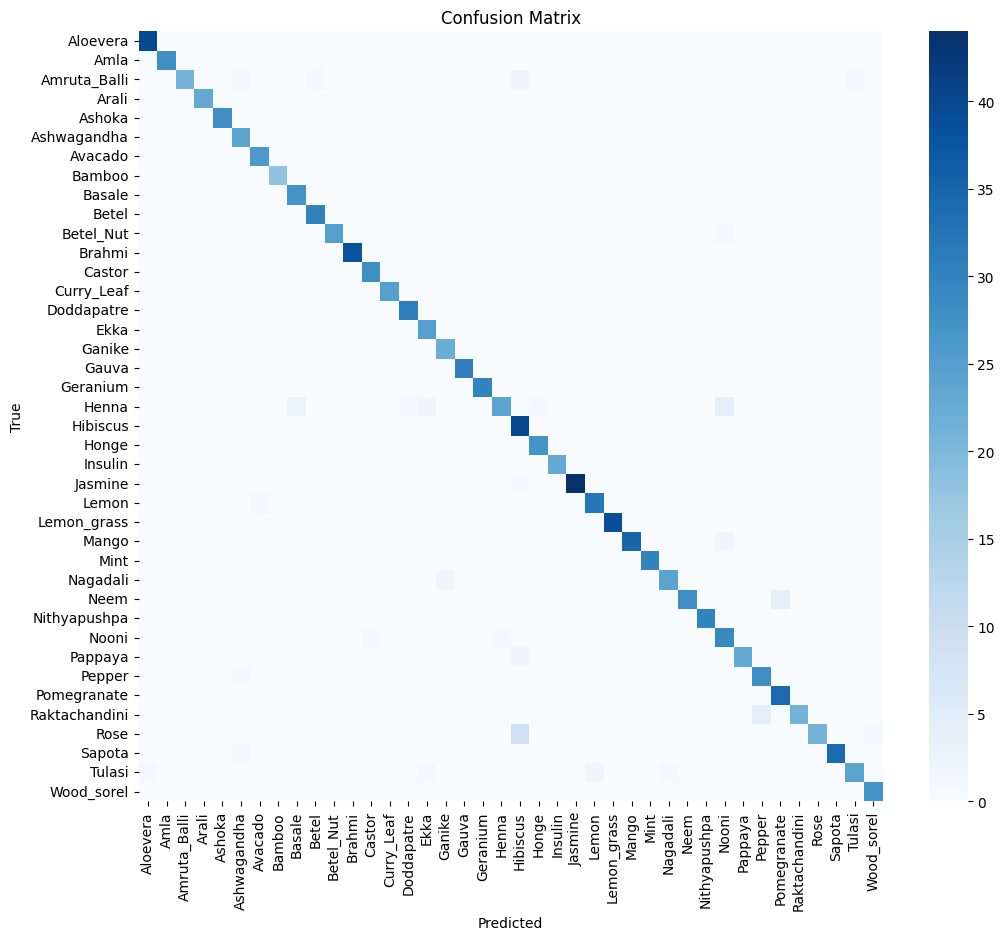

               precision    recall  f1-score   support

     Aloevera       0.98      1.00      0.99        40
         Amla       1.00      1.00      1.00        28
 Amruta_Balli       1.00      0.81      0.89        26
        Arali       1.00      1.00      1.00        23
       Ashoka       1.00      1.00      1.00        28
  Ashwagandha       0.89      1.00      0.94        24
      Avacado       0.96      1.00      0.98        26
       Bamboo       1.00      1.00      1.00        18
       Basale       0.90      1.00      0.95        27
        Betel       0.97      1.00      0.98        30
    Betel_Nut       1.00      0.96      0.98        26
       Brahmi       1.00      1.00      1.00        38
       Castor       0.97      1.00      0.98        28
   Curry_Leaf       1.00      1.00      1.00        25
   Doddapatre       0.97      1.00      0.98        31
         Ekka       0.89      1.00      0.94        25
       Ganike       0.92      1.00      0.96        22
        G

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))


In [ ]:
torch.save(model.state_dict(), "medicinal_leaf_model.pth")
